In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import cont2discrete
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import cvxpy as cp
import os

In [2]:
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"

train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1, 1)
Utrain = train_data["Utrain"].reshape(-1, 1)

Ytest = test_data["Ytest"].reshape(-1, 1)
Utest = test_data["Utest"].reshape(-1, 1)

print(Ytrain.shape, Utrain.shape, Ytest.shape, Utest.shape)

(2000, 1) (2000, 1) (1001, 1) (1001, 1)


In [3]:
#scalery
y_scaler = StandardScaler()
u_scaler = StandardScaler()

Ytrain_s = y_scaler.fit_transform(Ytrain)
Utrain_s = u_scaler.fit_transform(Utrain)

Ytest_s = y_scaler.transform(Ytest)
Utest_s = u_scaler.transform(Utest)

y_mean = float(y_scaler.mean_[0])
y_std  = float(y_scaler.scale_[0])
u_mean = float(u_scaler.mean_[0])
u_std  = float(u_scaler.scale_[0])

print("y_mean =", y_mean)
print("y_std  =", y_std)
print("u_mean =", u_mean)
print("u_std  =", u_std)

y_mean = 58.970747800586516
y_std  = 6.627504216471196
u_mean = 65.0
u_std  = 21.213203435596427


In [4]:
#NARX vstupy
def make_narx_dataset(Y, U):
    X = []
    T = []

    for k in range(1, len(Y) - 1):
        X.append([
            Y[k, 0],
            Y[k-1, 0],
            U[k, 0],
            U[k-1, 0]
        ])
        T.append(Y[k+1, 0])

    return np.array(X), np.array(T).reshape(-1, 1)

Xtr, Ttr = make_narx_dataset(Ytrain_s, Utrain_s)
Xte, Tte = make_narx_dataset(Ytest_s, Utest_s)

print(Xtr.shape, Ttr.shape)
print(Xte.shape, Tte.shape)

(1998, 4) (1998, 1)
(999, 4) (999, 1)


In [5]:
#nelineárny plant z dát
plant_model = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation="tanh",
    solver="adam",
    max_iter=5000,
    random_state=0
)

plant_model.fit(Xtr, Ttr.ravel())

train_score = plant_model.score(Xtr, Ttr.ravel())
test_score = plant_model.score(Xte, Tte.ravel())

print("Plant train R2:", train_score)
print("Plant test R2 :", test_score)

Plant train R2: 0.998012051669951
Plant test R2 : 0.997096088533882


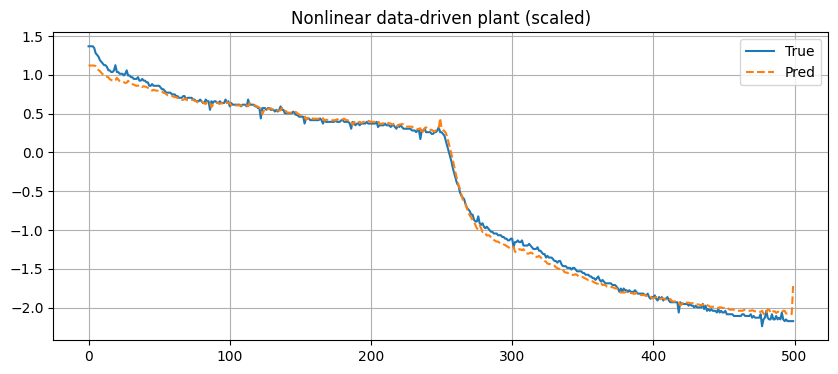

In [6]:
#prediction 
pred_te = plant_model.predict(Xte).reshape(-1, 1)

plt.figure(figsize=(10,4))
plt.plot(Tte[:500], label="True")
plt.plot(pred_te[:500], "--", label="Pred")
plt.grid(True)
plt.legend()
plt.title("Nonlinear data-driven plant (scaled)")
plt.show()

In [7]:
#plant simulator for cl
class DataPlant:
    def __init__(self, model):
        self.model = model
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0_scaled, u0_scaled=0.0):
        self.yk = float(y0_scaled)
        self.ykm1 = float(y0_scaled)
        self.ukm1 = float(u0_scaled)

    def step(self, uk_scaled):
        x = np.array([[self.yk, self.ykm1, uk_scaled, self.ukm1]])
        y_next = float(self.model.predict(x)[0])

        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk_scaled)

        return y_next

In [8]:
#strejc
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1/tau]])
B_c = np.array([[gain/tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

print("A_strejc =", A_strejc)
print("B_strejc =", B_strejc)

A_strejc = [[0.98540172]]
B_strejc = [[0.01640409]]


In [9]:
#koopman
def lift(y):
    return np.array([y, y**2, y**3, 1.0], dtype=float)

Z = []
Zp = []
U = []

for k in range(len(Ytrain_s)-1):
    zk = lift(float(Ytrain_s[k,0]))
    zkp1 = lift(float(Ytrain_s[k+1,0]))
    uk = float(Utrain_s[k,0])

    Z.append(zk)
    Zp.append(zkp1)
    U.append([uk])

Z = np.array(Z)       # (N, nz)
Zp = np.array(Zp)     # (N, nz)
U = np.array(U)       # (N, 1)

# least squares: Zp = Z A^T + U B^T
Phi = np.hstack([Z, U])   # (N, nz+1)
Theta, *_ = np.linalg.lstsq(Phi, Zp, rcond=None)

nz = Z.shape[1]
A_koop = Theta[:nz, :].T
B_koop = Theta[nz:, :].T

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)

A_koop shape: (4, 4)
B_koop shape: (4, 1)


In [10]:
#koopman mpc
def mpc_koopman(A, B, z0, z_ref, N=20, Qz=None, Qu=0.1, Qdu=0.1,
                umin=None, umax=None, u_prev=0.0):
    nz = A.shape[0]

    if Qz is None:
        Qz = np.eye(nz)

    U = cp.Variable((1, N))
    Z = cp.Variable((nz, N + 1))

    constraints = [Z[:, [0]] == z0.reshape(-1, 1)]
    objective = 0

    z_ref = z_ref.reshape(-1, 1)

    for k in range(N):
        constraints += [Z[:, [k+1]] == A @ Z[:, [k]] + B @ U[:, [k]]]

        objective += cp.quad_form(Z[:, [k]] - z_ref, Qz)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - u_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if umin is not None:
            constraints += [U[:, [k]] >= umin]
        if umax is not None:
            constraints += [U[:, [k]] <= umax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev)

    return float(U.value[0, 0])

In [11]:
#strejc mpc
def mpc_strejc(A, B, C, x0, x_ref, N=20, Qy=10.0, Qu=0.1, Qdu=0.1,
               umin=None, umax=None, u_prev=0.0):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - x_ref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - u_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if umin is not None:
            constraints += [U[:, [k]] >= umin]
        if umax is not None:
            constraints += [U[:, [k]] <= umax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev)

    return float(U.value[0, 0])

In [12]:
#losed loop
umin = (20.0 - u_mean) / u_std
umax = (100.0 - u_mean) / u_std

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 150

Qz = np.eye(A_koop.shape[0])
Qy = 10.0
Qu = 0.05
Qdu = 0.1
N = 30

y_ref_phys = y_mean
y_ref_scaled = (y_ref_phys - y_mean) / y_std

all_results = {}

In [13]:
#cl pre initial cond
for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    y0_scaled = (T0 - y_mean) / y_std

    # ---------- Koopman MPC ----------
    plant_k = DataPlant(plant_model)
    plant_k.reset(y0_scaled, u0_scaled=0.0)

    z0 = lift(y0_scaled).reshape(-1, 1)
    z_ref = lift(y_ref_scaled).reshape(-1, 1)

    y_store_k = [T0]
    u_store_k = []
    u_prev_k = 0.0

    for t in range(sim_length):
        uk = mpc_koopman(
            A_koop, B_koop,
            z0, z_ref,
            N=N, Qz=Qz, Qu=Qu, Qdu=Qdu,
            umin=umin, umax=umax,
            u_prev=u_prev_k
        )

        y_next_scaled = plant_k.step(uk)
        y_next_phys = y_next_scaled * y_std + y_mean
        u_phys = uk * u_std + u_mean

        z0 = lift(y_next_scaled).reshape(-1, 1)

        y_store_k.append(y_next_phys)
        u_store_k.append(u_phys)
        u_prev_k = uk

    # ---------- Strejc MPC ----------
    plant_s = DataPlant(plant_model)
    plant_s.reset(y0_scaled, u0_scaled=0.0)

    x_s = np.array([[y0_scaled]])
    x_ref_s = np.array([[y_ref_scaled]])

    y_store_s = [T0]
    u_store_s = []
    u_prev_s = 0.0

    for t in range(sim_length):
        us = mpc_strejc(
            A_strejc, B_strejc, C_strejc,
            x_s, x_ref_s,
            N=N, Qy=Qy, Qu=Qu, Qdu=Qdu,
            umin=umin, umax=umax,
            u_prev=u_prev_s
        )

        y_next_scaled = plant_s.step(us)
        y_next_phys = y_next_scaled * y_std + y_mean
        u_phys = us * u_std + u_mean

        x_s = np.array([[y_next_scaled]])

        y_store_s.append(y_next_phys)
        u_store_s.append(u_phys)
        u_prev_s = us

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


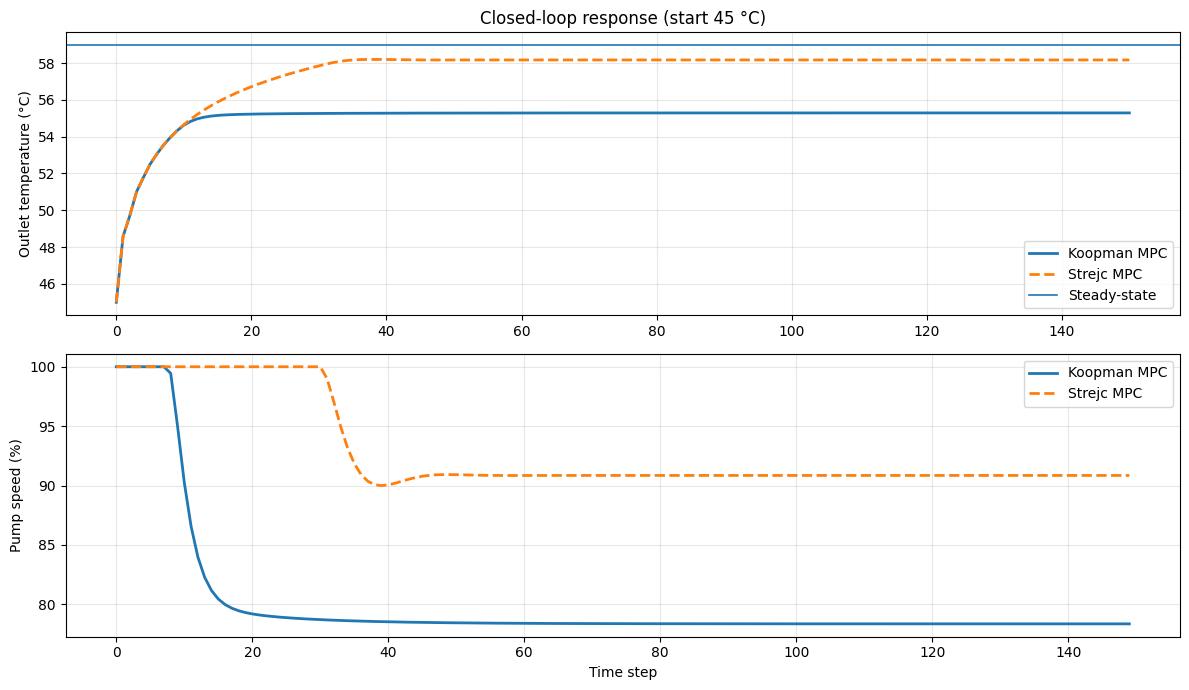

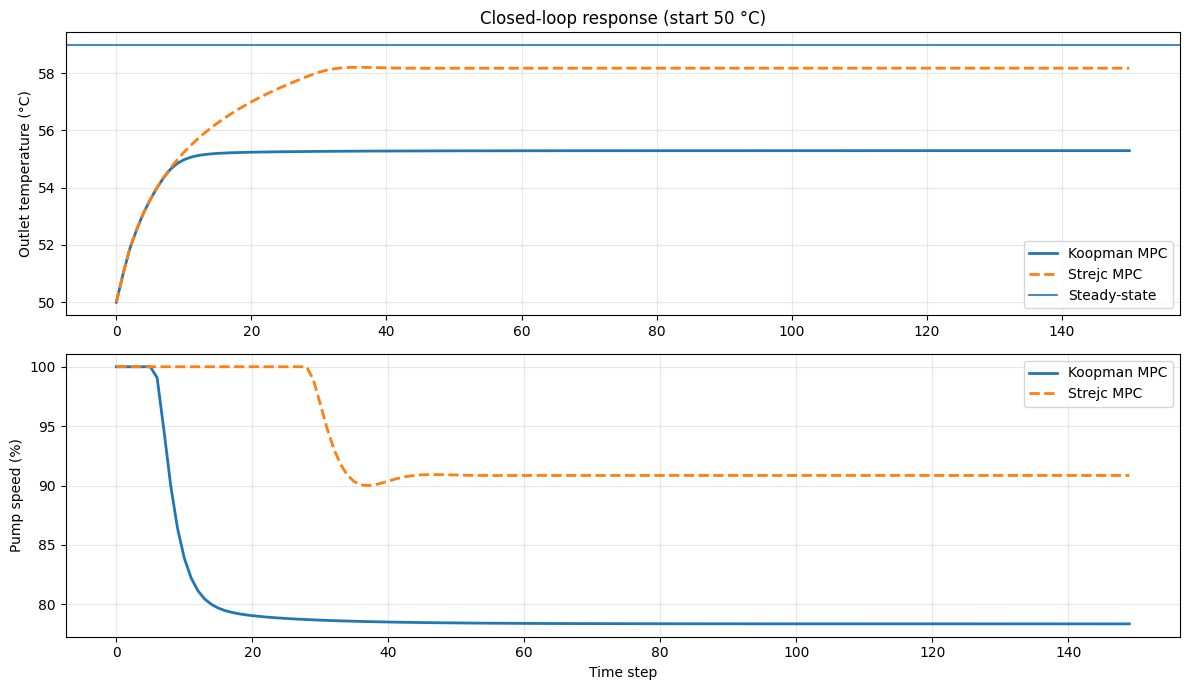

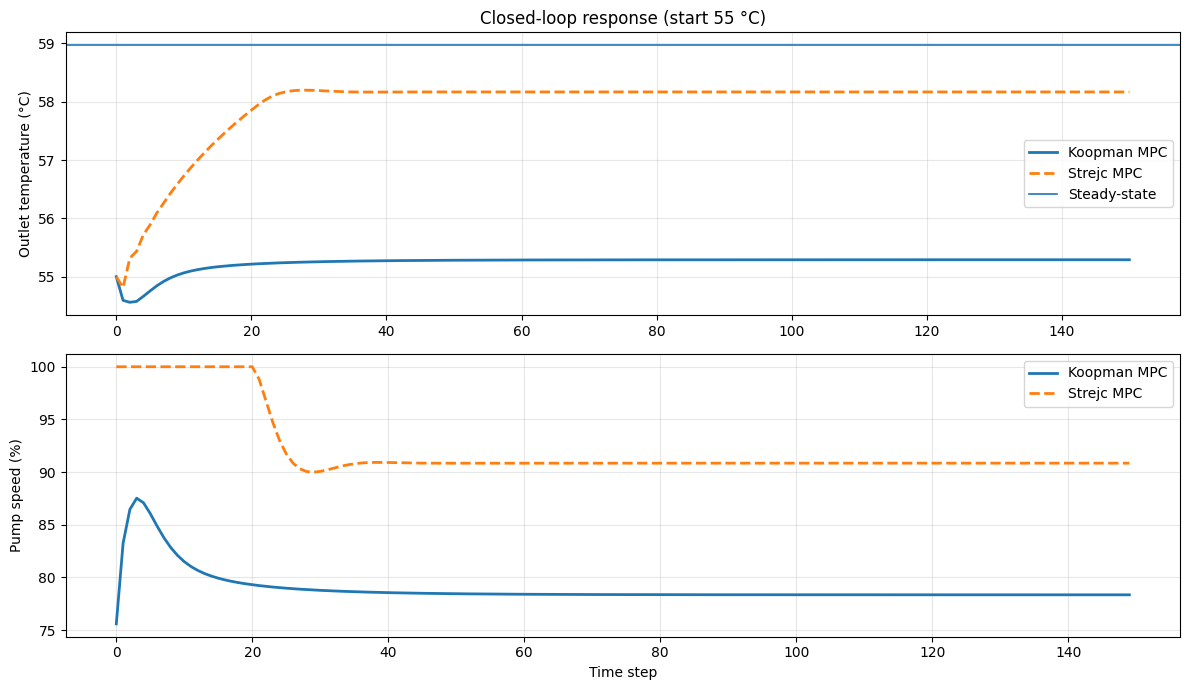

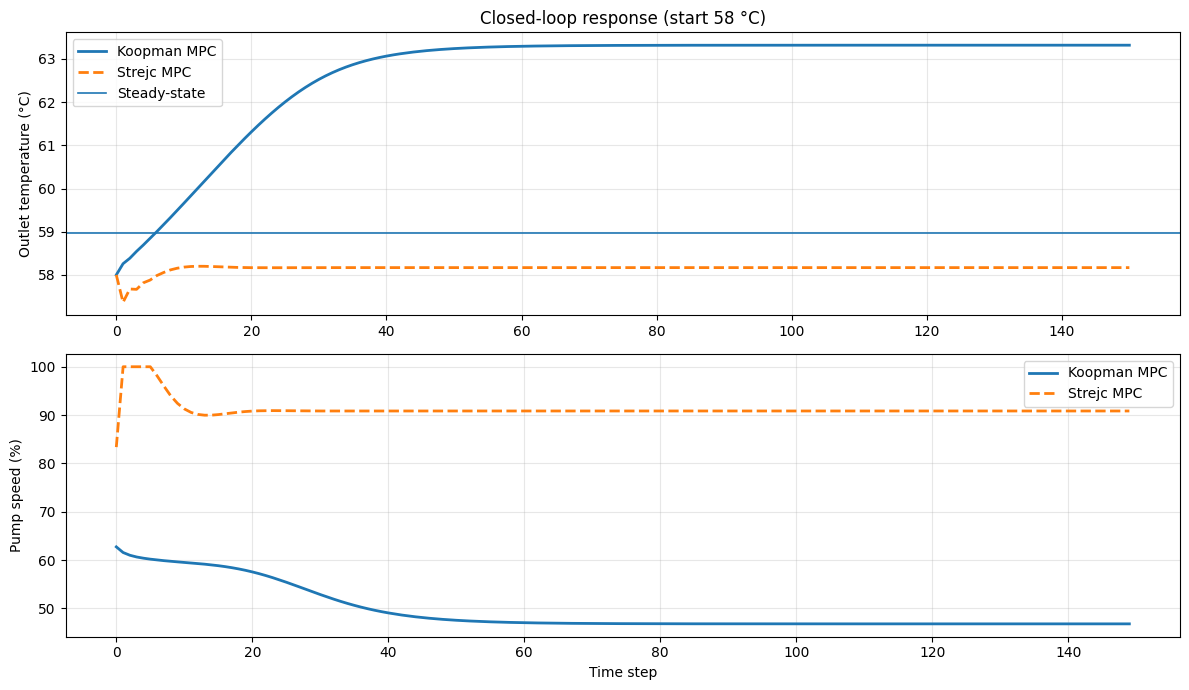

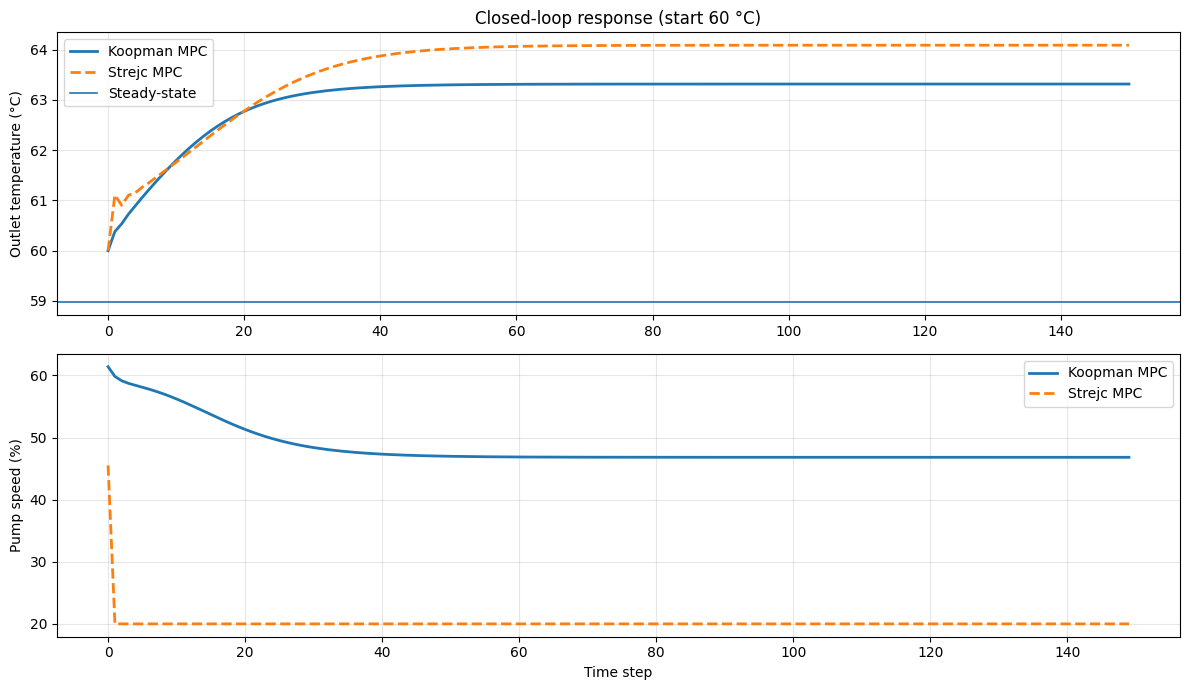

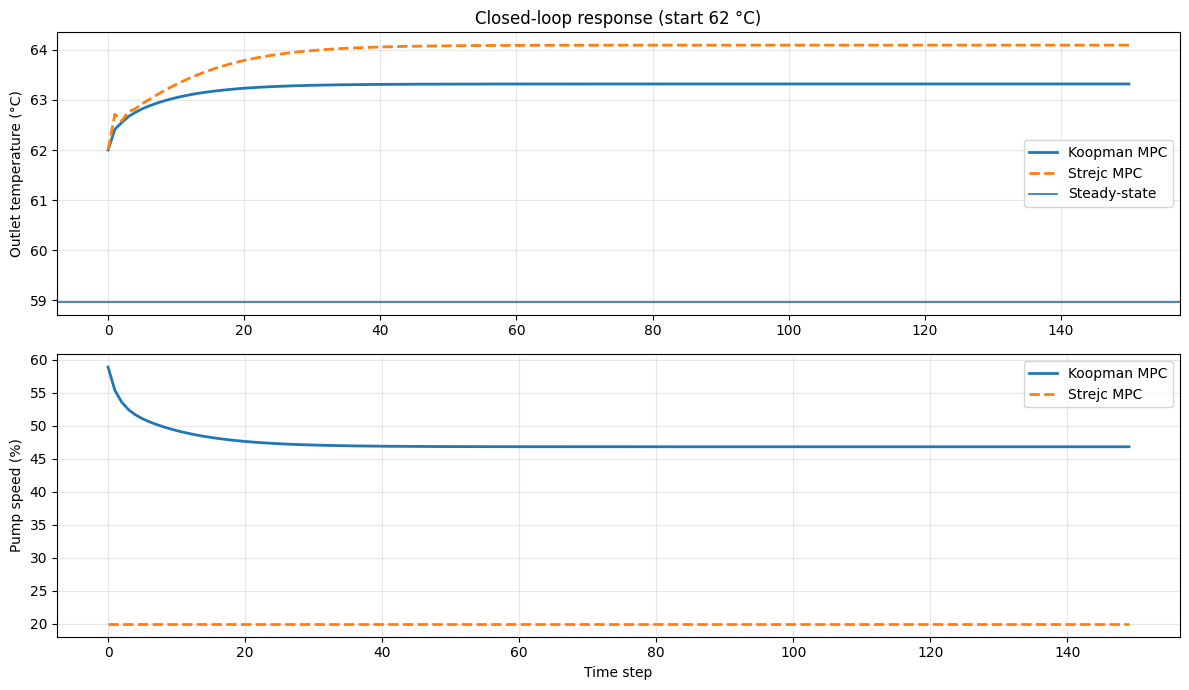

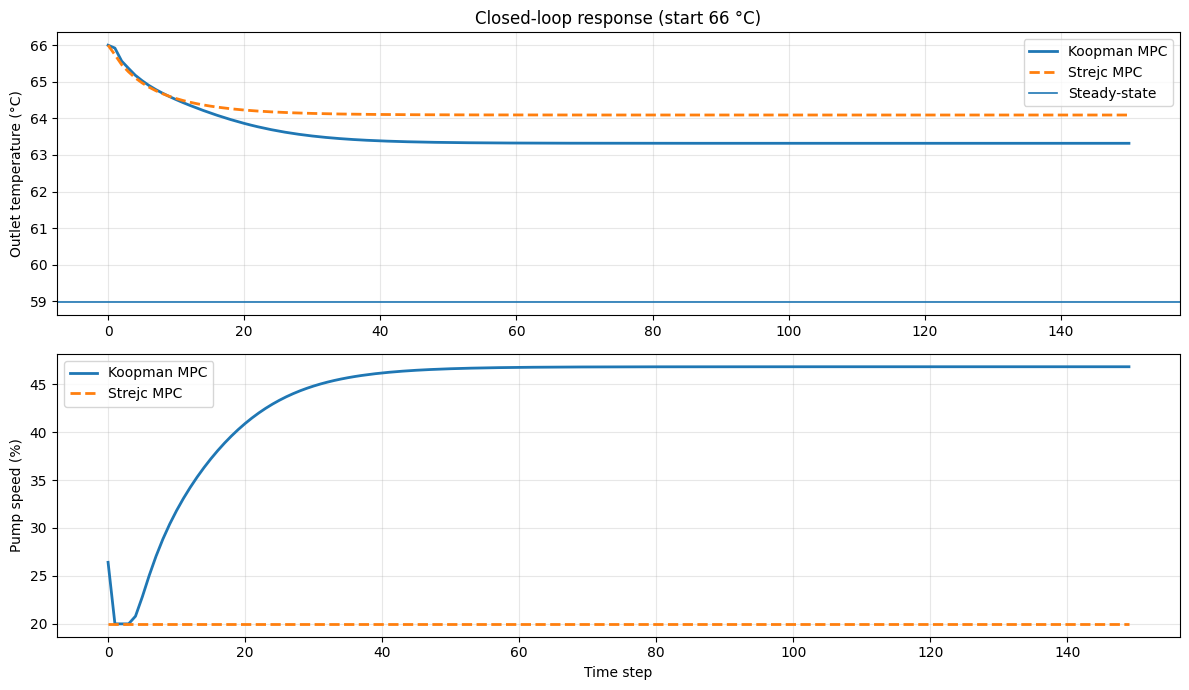

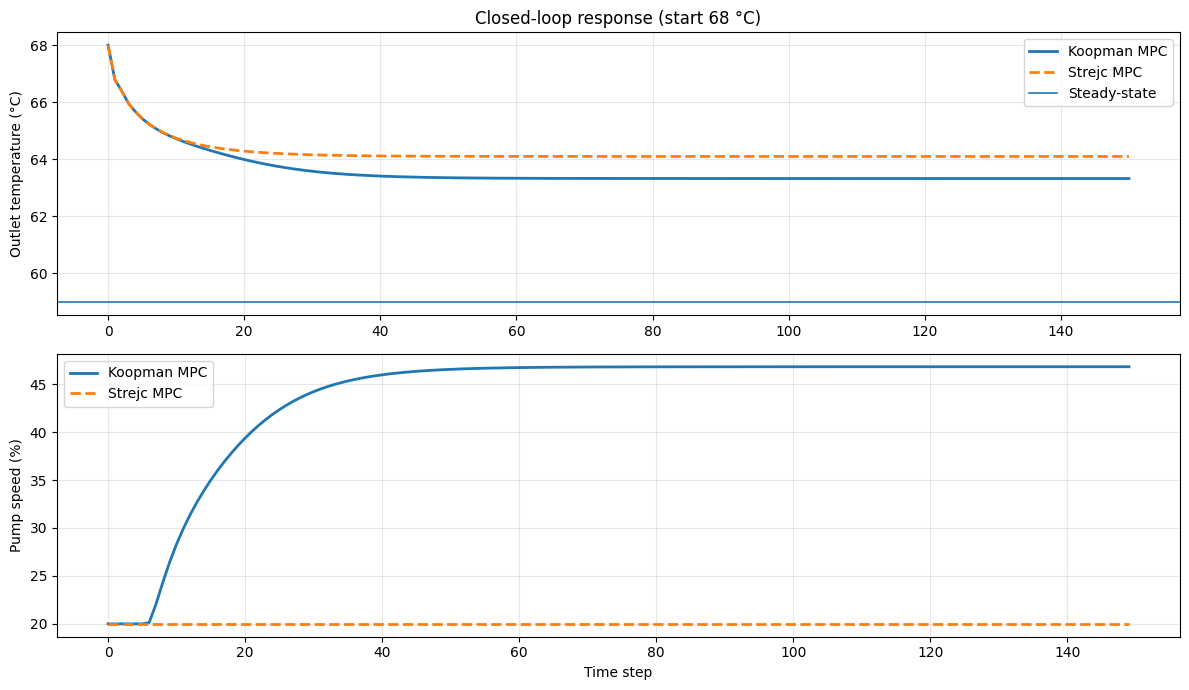

In [14]:
#plots
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_mean, linewidth=1.2, label="Steady-state")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [15]:
#summary metrics 
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_mean
    e_s = res["y_strejc"][:-1] - y_mean

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    uk_scaled = (res["u_koop"] - u_mean) / u_std
    us_scaled = (res["u_strejc"] - u_mean) / u_std
    yk_scaled = (res["y_koop"][:-1] - y_mean) / y_std
    ys_scaled = (res["y_strejc"][:-1] - y_mean) / y_std

    obj_k = np.sum(10.0 * yk_scaled**2 + 0.05 * uk_scaled**2)
    obj_s = np.sum(10.0 * ys_scaled**2 + 0.05 * us_scaled**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S       Obj_K       Obj_S
0  45  4.145241  2.415946  594.650967  222.789847  591.077220  212.497057
1  50  3.910233  1.939798  577.139082  199.263664  526.187974  141.542401
2  55  3.731628  1.214679  559.384865  153.982652  478.824739   62.931716
3  58  3.933300  0.826251  562.391763  123.099351  532.674061   34.809074
4  60  4.137097  4.773873  613.038627  704.654742  589.293945  811.841963
5  62  4.292667  4.992165  643.368732  747.049227  634.523509  884.827570
6  66  4.597428  5.225556  685.234596  782.627013  729.617991  966.265972
7  68  4.683249  5.297663  694.569607  791.103967  757.313971  992.178990



ARX ABS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"

train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)

Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

# choose operating point
y_ss = 58.3377
u_ss = 63.0883

dYtrain = Ytrain - y_ss
dUtrain = Utrain - u_ss

dYtest = Ytest - y_ss
dUtest = Utest - u_ss

In [76]:
#fit arx plant 
# def make_arx_data(dy, du):
#     X = []
#     T = []
#     for k in range(1, len(dy)-1):
#         X.append([dy[k], dy[k-1], du[k], du[k-1]])
#         T.append(dy[k+1])
#     return np.array(X), np.array(T)

# Xtr, Ttr = make_arx_data(dYtrain, dUtrain)
# Xte, Tte = make_arx_data(dYtest, dUtest)

# theta, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)

# print("ARX theta =", theta)

# pred_te = Xte @ theta

# plt.figure(figsize=(10,4))
# plt.plot(Tte[:500], label="True Δy")
# plt.plot(pred_te[:500], "--", label="Pred Δy")
# plt.grid(True)
# plt.legend()
# plt.title("ARX plant one-step prediction")
# plt.show()

theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]


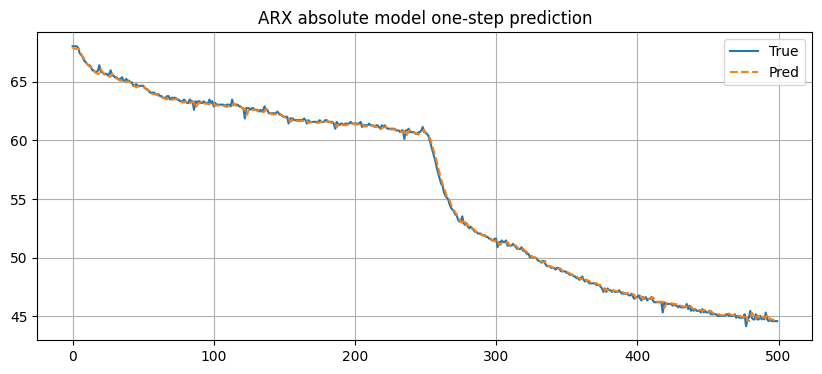

In [77]:
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y)-1):
        X.append([Y[k], Y[k-1], U[k], U[k-1], 1.0])
        T.append(Y[k+1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
Xte, Tte = make_arx_abs_data(Ytest, Utest)

theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

pred_te = Xte @ theta_abs

plt.figure(figsize=(10,4))
plt.plot(Tte[:500], label="True")
plt.plot(pred_te[:500], "--", label="Pred")
plt.grid(True)
plt.legend()
plt.title("ARX absolute model one-step prediction")
plt.show()

In [78]:
# #arx plant 
# class ARXPlant:
#     def __init__(self, theta, y_ss, u_ss):
#         self.theta = theta
#         self.y_ss = y_ss
#         self.u_ss = u_ss
#         self.dy_k = None
#         self.dy_km1 = None
#         self.du_km1 = None

#     def reset(self, y0, u0=None):
#         if u0 is None:
#             u0 = self.u_ss
#         self.dy_k = y0 - self.y_ss
#         self.dy_km1 = self.dy_k
#         self.du_km1 = u0 - self.u_ss

#     def step(self, u):
#         du_k = u - self.u_ss
#         x = np.array([self.dy_k, self.dy_km1, du_k, self.du_km1])
#         dy_next = float(x @ self.theta)

#         self.dy_km1 = self.dy_k
#         self.dy_k = dy_next
#         self.du_km1 = du_k

#         y_next = self.y_ss + dy_next
#         return y_next

In [79]:
class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)

        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)

        return y_next

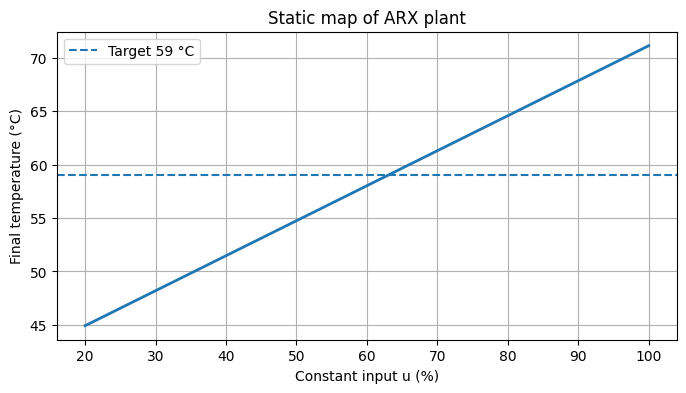

In [80]:
#static plant 
plant = ARXPlantAbs(theta_abs)

# def rollout_const_u(T0, u_const, n=150):
#     plant.reset(T0)
#     ys = [T0]
#     for _ in range(n):
#         ys.append(plant.step(u_const))
#     return np.array(ys)

# for u_const in [20, 35, 50, 65, 80]:
#     ys = rollout_const_u(68, u_const, 150)
#     plt.plot(ys, label=f"u={u_const}%")

# plt.axhline(y_ss, linestyle="--", color="k", label="y_ss")
# plt.grid(True)
# plt.legend()
# plt.title("ARX plant: response for constant input")
# plt.ylabel("Temperature (°C)")
# plt.xlabel("Time step")
# plt.show()

def rollout_const_u_abs(theta, y0, u_const, n=300):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)

    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)


def final_temp_for_u(theta, y0, u_const, n=300):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return ys[-1]

u_grid = np.linspace(20, 100, 81)
y_final = []

for u in u_grid:
    y_final.append(final_temp_for_u(theta_abs, 59.0, u, n=300))

plt.figure(figsize=(8,4))
plt.plot(u_grid, y_final, linewidth=2)
plt.axhline(59.0, linestyle="--", label="Target 59 °C")
plt.grid(True)
plt.xlabel("Constant input u (%)")
plt.ylabel("Final temperature (°C)")
plt.legend()
plt.title("Static map of ARX plant")
plt.show()

In [81]:
idx = np.argmin(np.abs(np.array(y_final) - 59.0))
u_eq = float(u_grid[idx])

print("Estimated equilibrium input for 59 °C:", u_eq)
print("Final temperature at u_eq:", y_final[idx])

Estimated equilibrium input for 59 °C: 63.0
Final temperature at u_eq: 59.01034814234463


In [82]:
#rx strejc
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1/tau]])
B_c = np.array([[gain/tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

print("A_strejc =", A_strejc)
print("B_strejc =", B_strejc)

A_strejc = [[0.98540172]]
B_strejc = [[0.01640409]]


In [83]:
#arx koop
def lift_dy(dy):
    return np.array([dy, dy**2, dy**3, 1.0], dtype=float)

Z = []
Zp = []
DU = []

for k in range(len(dYtrain)-1):
    zk = lift_dy(dYtrain[k])
    zkp1 = lift_dy(dYtrain[k+1])
    duk = dUtrain[k]

    Z.append(zk)
    Zp.append(zkp1)
    DU.append([duk])

Z = np.array(Z)
Zp = np.array(Zp)
DU = np.array(DU)

Phi = np.hstack([Z, DU])
Theta, *_ = np.linalg.lstsq(Phi, Zp, rcond=None)

nz = Z.shape[1]
A_koop = Theta[:nz, :].T
B_koop = Theta[nz:, :].T

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("||B_koop|| =", np.linalg.norm(B_koop))

A_koop shape: (4, 4)
B_koop shape: (4, 1)
||B_koop|| = 1.0232311741868476


In [84]:
#m=pc arx strejc
def mpc_strejc_dev(A, B, C, x0, yref, N=20, Qy=10.0, Qu=0.1, Qdu=0.1,
                   dumin=None, dumax=None, du_prev=0.0):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)

    return float(U.value[0, 0])

In [85]:
#mpc ar xkoop
def mpc_koopman_dev(A, B, z0, zref, N=20, Qz=None, Qu=0.1, Qdu=0.1,
                    dumin=None, dumax=None, du_prev=0.0):
    nz = A.shape[0]

    if Qz is None:
        Qz = np.eye(nz)

    U = cp.Variable((1, N))
    Z = cp.Variable((nz, N + 1))

    constraints = [Z[:, [0]] == z0.reshape(-1, 1)]
    objective = 0
    zref = zref.reshape(-1, 1)

    for k in range(N):
        constraints += [Z[:, [k+1]] == A @ Z[:, [k]] + B @ U[:, [k]]]

        objective += cp.quad_form(Z[:, [k]] - zref, Qz)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)

    return float(U.value[0, 0])

In [86]:
#cl
u_min = 20.0
u_max = 100.0

dumin = u_min - u_ss
dumax = u_max - u_ss

print("dumin =", dumin)
print("dumax =", dumax)
temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

N = 30
Qy = 10.0
Qz = np.diag([10.0, 1.0, 0.1, 0.0])
Qu = 0.05
Qdu = 0.1

y_ref = 0.0          # deviation reference => physical target is y_ss
z_ref = lift_dy(y_ref).reshape(-1, 1)

all_results = {}

dumin = -43.0883
dumax = 36.9117


In [87]:
#mpc
for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    dy0 = T0 - y_ss
    z0 = lift_dy(dy0).reshape(-1, 1)

    y_store_k = [T0]
    u_store_k = []
    du_prev_k = 0.0

    for t in range(sim_length):
        du_k = mpc_koopman_dev(
            A_koop, B_koop,
            z0, z_ref,
            N=N, Qz=Qz, Qu=Qu, Qdu=Qdu,
            dumin=dumin, dumax=dumax,
            du_prev=du_prev_k
        )

        u_k = u_ss + du_k
        y_next = plant_k.step(u_k)

        dy_next = y_next - y_ss
        z0 = lift_dy(dy_next).reshape(-1, 1)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        du_prev_k = du_k

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []
    du_prev_s = 0.0

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, y_ref,
            N=N, Qy=Qy, Qu=Qu, Qdu=Qdu,
            dumin=dumin, dumax=dumax,
            du_prev=du_prev_s
        )

        u_s = u_ss + du_s
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])

        y_store_s.append(y_next)
        u_store_s.append(u_s)
        du_prev_s = du_s

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


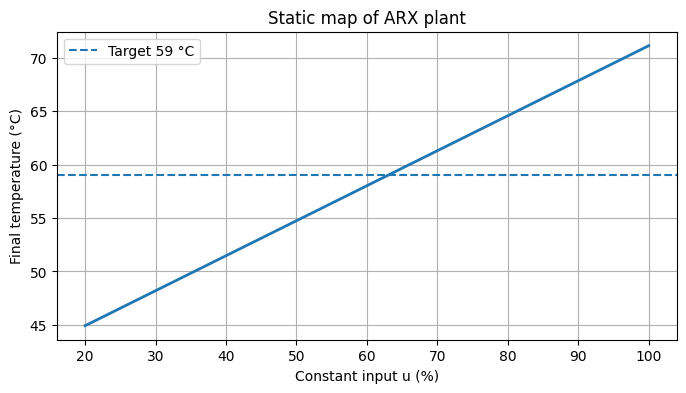

Estimated equilibrium input for 59 °C: 63.0
Final temperature at u_eq: 59.01034814234463


In [88]:
u_grid = np.linspace(20, 100, 81)
y_final = []

for u in u_grid:
    y_final.append(final_temp_for_u(theta_abs, 59.0, u, n=300))

plt.figure(figsize=(8,4))
plt.plot(u_grid, y_final, linewidth=2)
plt.axhline(59.0, linestyle="--", label="Target 59 °C")
plt.grid(True)
plt.xlabel("Constant input u (%)")
plt.ylabel("Final temperature (°C)")
plt.legend()
plt.title("Static map of ARX plant")
plt.show()

idx = np.argmin(np.abs(np.array(y_final) - 59.0))
u_eq = float(u_grid[idx])

print("Estimated equilibrium input for 59 °C:", u_eq)
print("Final temperature at u_eq:", y_final[idx])

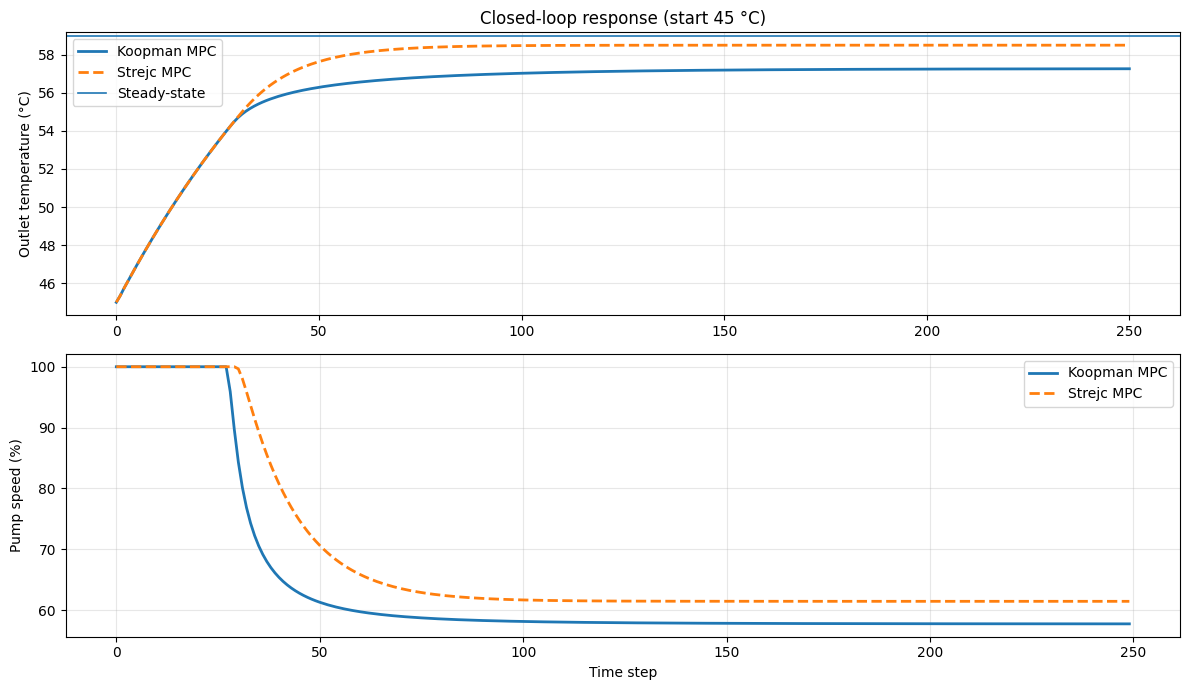

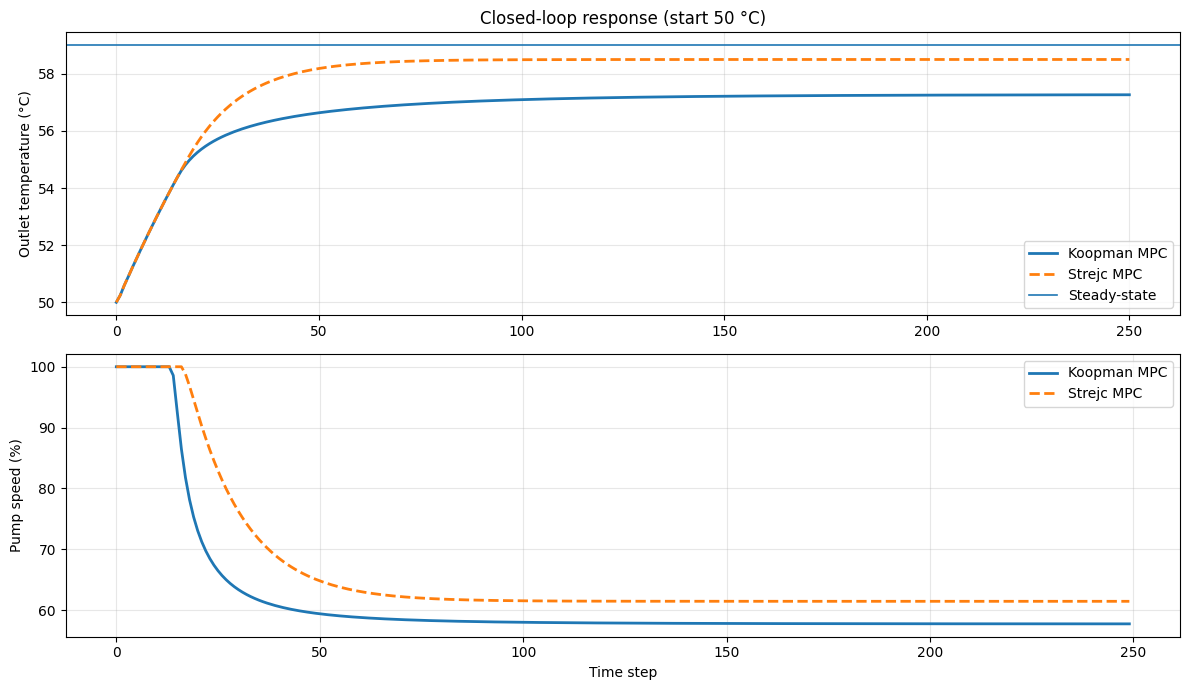

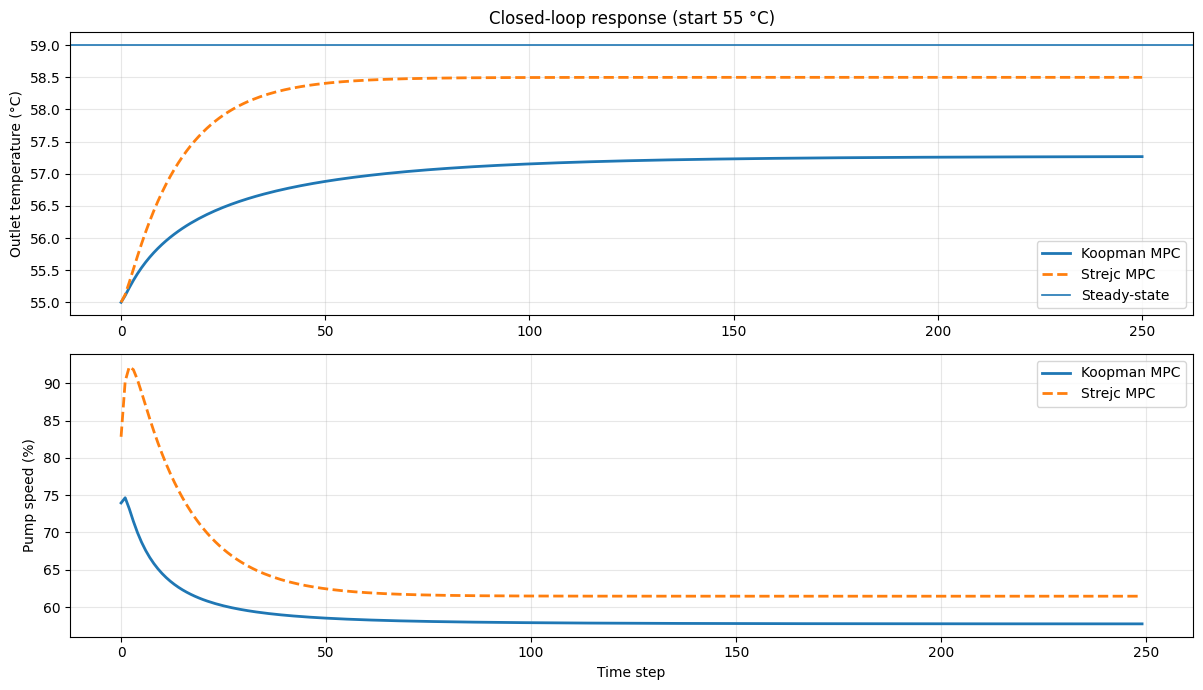

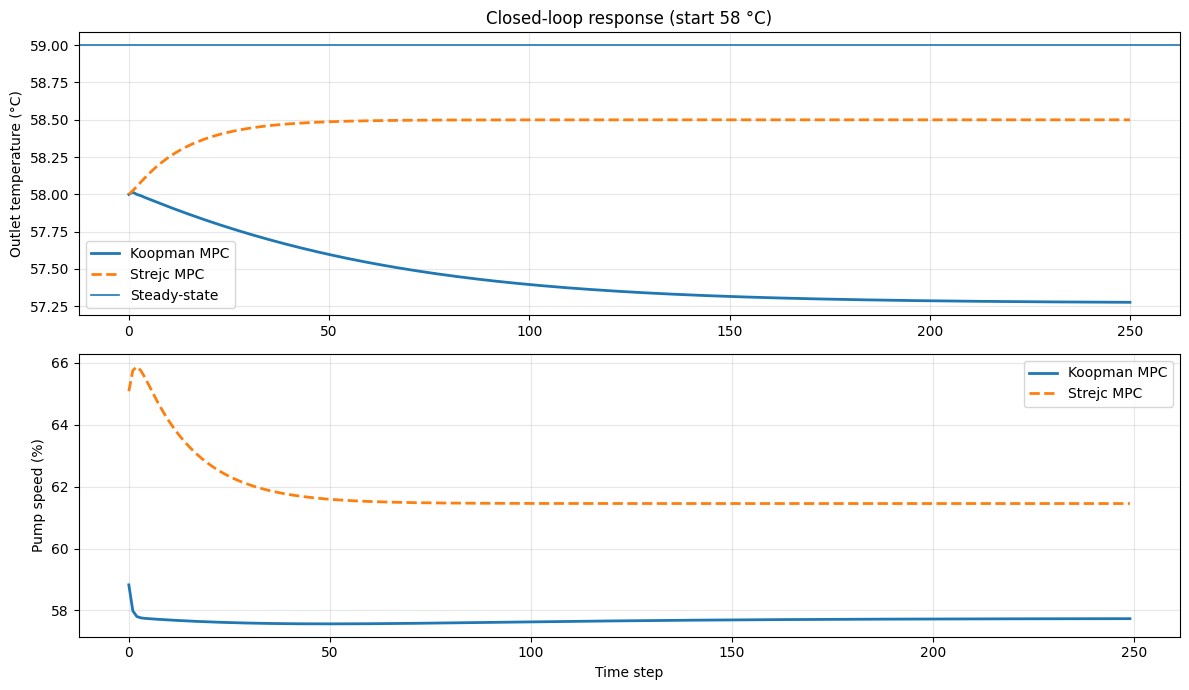

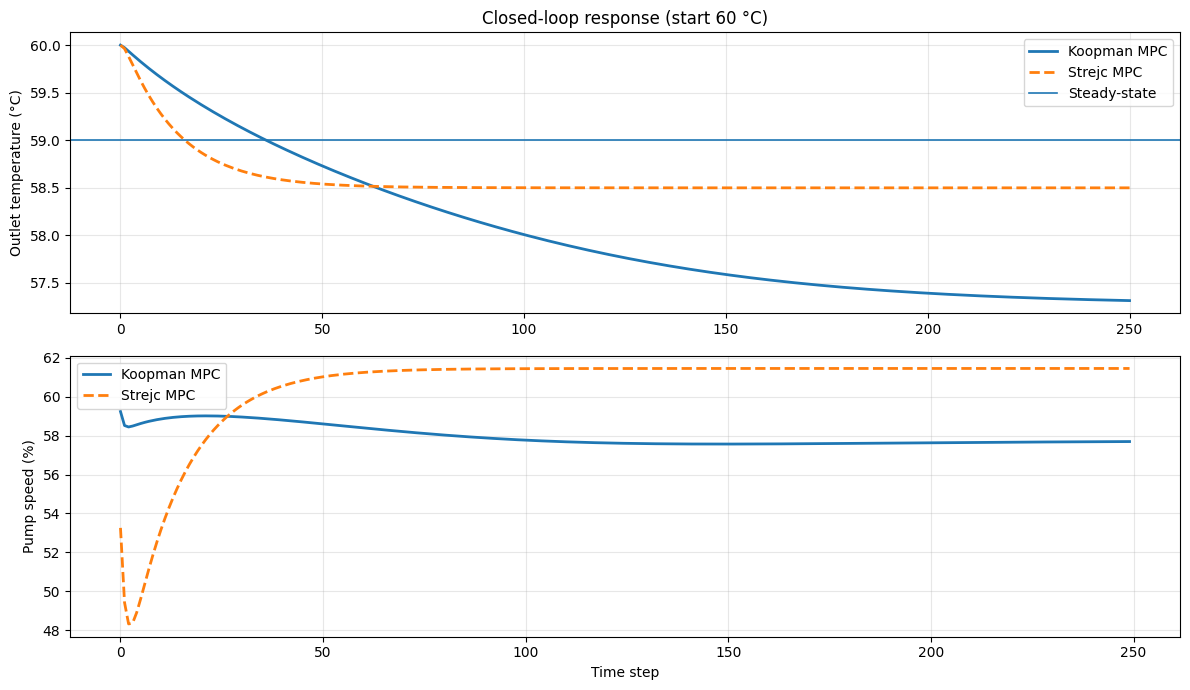

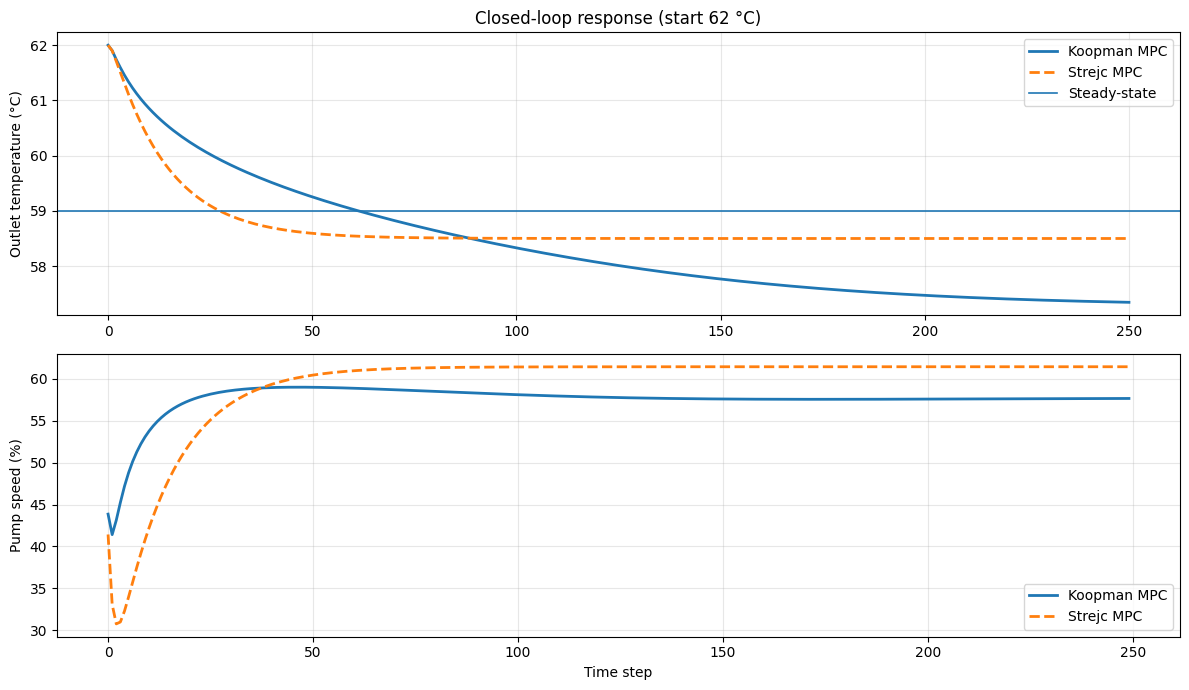

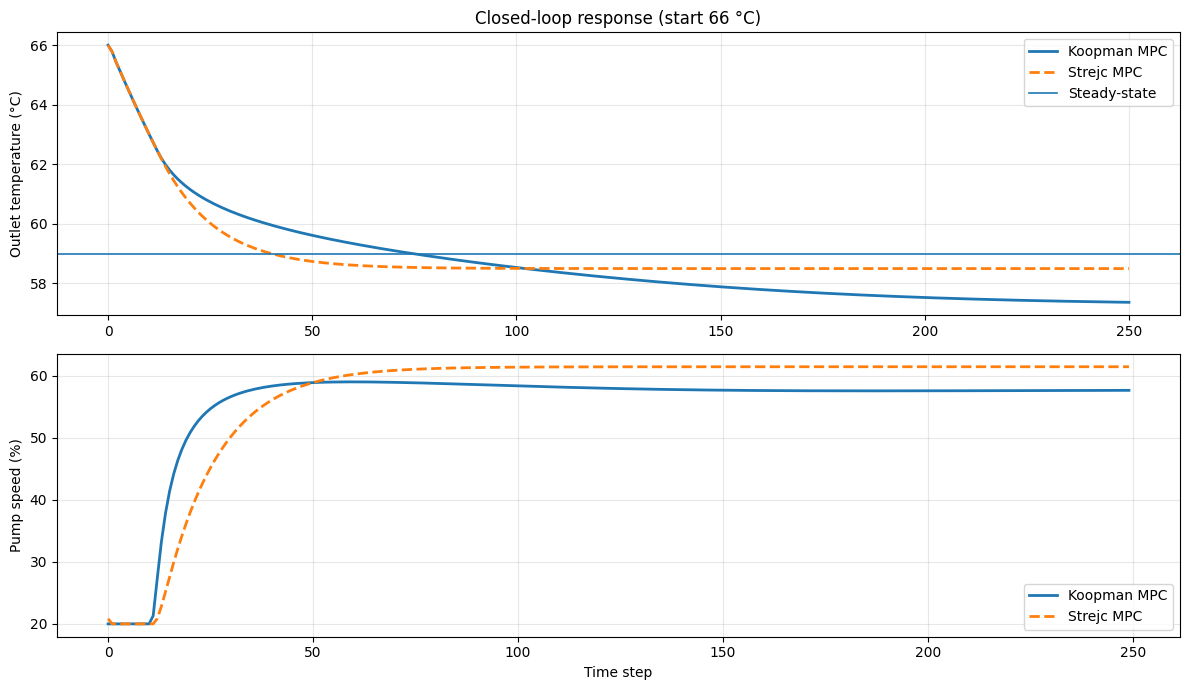

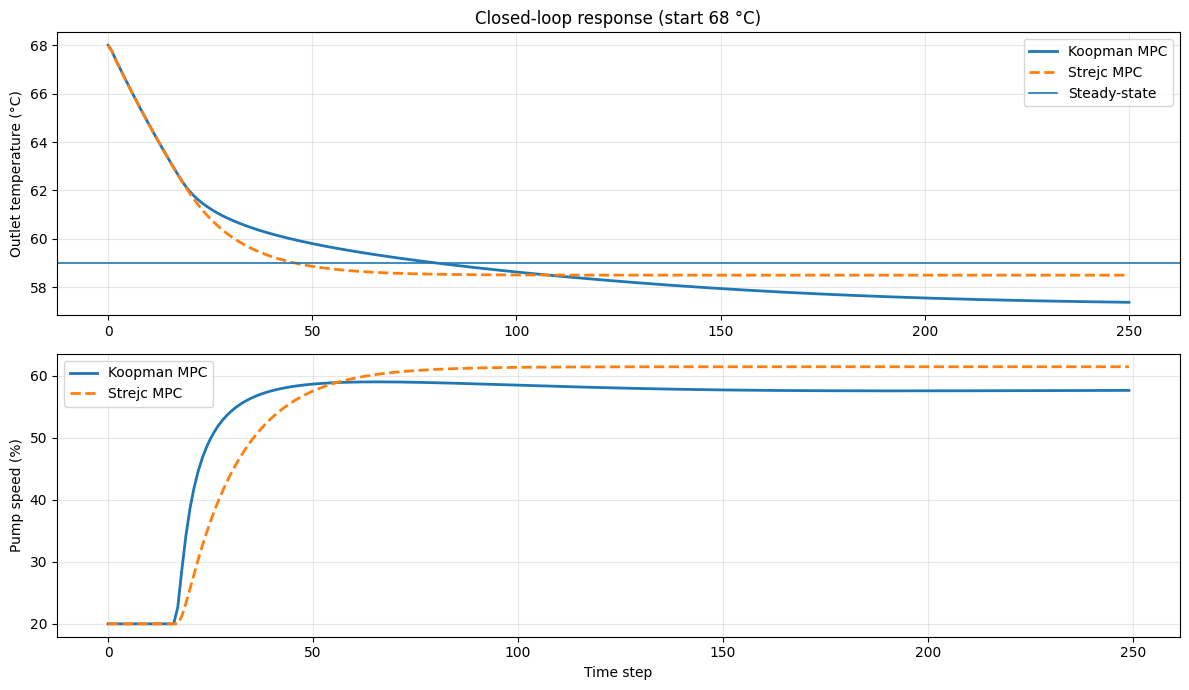

In [92]:
#plot
y_ss = 59
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_ss, linewidth=1.2, label="Steady-state")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [93]:
#sum
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_ss
    e_s = res["y_strejc"][:-1] - y_ss

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy * e_k**2 + Qu * du_k**2)
    obj_s = np.sum(Qy * e_s**2 + Qu * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.795554  3.375546  716.700376  431.281614  38326.476586  31045.901197
1  50  2.665432  1.985656  582.314123  280.131660  19167.686780  11494.680608
2  55  2.033896  0.925725  497.095387  177.261830  10663.591853   2565.444589
3  58  1.571553  0.535972  389.723432  132.360973   6541.151256    748.962732
4  60  1.203836  0.484062  270.909237  117.710023   3952.641245    743.761976
5  62  1.239254  0.665467  274.714771  136.277703   4294.186117   1703.190939
6  66  1.700679  1.382255  321.994789  197.307522   8884.759076   6659.217307
7  68  2.098485  1.864016  360.165325  241.883555  13189.881714  11107.114029


In [ ]:
#bias
target_y = 59.0
y0_eq = 59.0

u_grid = np.linspace(20, 100, 801)   # finer grid than before
y_final = []

for u in u_grid:
    y_final.append(final_temp_for_u(theta_abs, y0_eq, u, n=500))

y_final = np.array(y_final)

idx = np.argmin(np.abs(y_final - target_y))
u_eq = float(u_grid[idx])

print("Estimated equilibrium input for 59 °C:", u_eq)
print("Final temperature at u_eq:", y_final[idx])
print("Input bias relative to old u_ss:", u_eq - 59.01034814234463)

Estimated equilibrium input for 59 °C: 63.0
Final temperature at u_eq: 59.01044373859624
Input bias relative to old u_ss: 3.9896518576553675


: 